In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [ ]:
! pip install pyreadstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 33.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Для выполнения заданий ниже вам необходимо пользоваться данными, которые вы можете сказать по [ссылке](https://disk.yandex.ru/d/W2tG4krgbjk4mw)


Кодбуки с описанием переменных для каждой волны обследования доступны по той же ссылке в папке codebooks.
Обратите внимание, что каждому индивиду в файле присвоен определённый вес (переменные VESA, VES_KVART, VESA_OB). Так как опрос проводится с использованием выборки, для распространения результатов на всё население России (генеральную совокупность) при подсчёте агрегированных значений каждого индивида необходимо учитывать с его весом. Например:
- для расчёта среднего возраста респонендтов в каждом месяце необходимо применить [эту формулу](https://disk.yandex.ru/i/osE6kVbHbAtacA), где N - число индивидов, опрощенных в данном месяце.
- для подсчёта аналогичного показателя за весь год необходимо применять годовые веса (переменная VESAOB) -> [пример](https://disk.yandex.ru/i/PrS3BLCuRLombQ)

In [ ]:
Задание выполнили Морозова Анисия, Воронова Алиса, Платонова Ксения.

# Задание №1: Расчет уровня безработицы

Загрузите данные всех волн (2010–2023 гг.)

Объедините данные в один гармонизированный DataFrame, оставив следующие переменные:
- Идентификаторы: `year`, `quarter`, `month`, `region`, `vesa`, `ves_kvart`, `vesa_ob`
- Соцдем: `settlement_type`, `gender`, `age`, `age_5group`, `education`, `marital_status`, `year_vocational_edu`
- Экономическая активность: `labor_force_status`, `social_category`
- Характеристики работы: `workplace`, `employment_contract`, `economic_activity_group`, `job_profession_match`
- Информальность: `informal_employment`

In [ ]:
names_map_raw = {  #вспомогательный словарь для переименовывания колонок
    "god": "year",
    "kvartal" : "quarter",
    "mes": "month",
    "kvartal": "quarter",
    "territ" : "region",
    "vesa": "vesa",
    "vesa_kvart": "vesa_kvart",
    "vesa_ob": "vesa_ob",
    "posel" : "settlement_type",
    "nas_pol": "gender",
    "nas_vozr" : "age",
    "nas_voz2" : "age_5group",
    "nasobraz" : "education",
    "nasbrach" : "marital_status",
    "god_okonch" : "year_vocational_edu",
    "struktak": "labour_force_status",
    "kateg" : "social_category",
    "v_os" : "workplace",
    "naim_zan" : "employment_contract",
    "vid_osn1" : "economic_activity_group",
    "sv_prof" : "job_profession_match",
    "zan_nf" : "informal_employment"
}
names_map = {}  #итоговый словарь
for k, v in names_map_raw.items():
  names_map[k] = v
  names_map[k.upper()] = v  #добавляем ключи в верхнем регистре, так как с 2022 регистр меняется

In [ ]:
import pyreadstat

folder_path = "/content/drive/MyDrive/ORS"
required_columns = list(names_map.keys())
all_data_harmonized = []  #список для хранения обработанных данных
all_meta = []             #список для хранения метаданных каждого файла

for file in os.listdir(folder_path):  #проходимся по файлам с данными из папки
    if file.endswith(".sav"):
        file_path = os.path.join(folder_path, file) #формируем полный путь файла
        df, meta = pyreadstat.read_sav(file_path)

        available_columns = [col for col in required_columns if col in df.columns]  #выбираем нужные колонки
        df_filtered = df[available_columns]
        all_data_harmonized.append(df_filtered.rename(columns=names_map))
        all_meta.append(meta)

ors_df = pd.concat(all_data_harmonized, ignore_index=True)   #объединяем в общий датафрейм

In [ ]:
ors_df

,year,quarter,month,region,vesa,vesa_kvart,vesa_ob,settlement_type,gender,age,...,education,marital_status,year_vocational_edu,labour_force_status,social_category,workplace,employment_contract,job_profession_match,informal_employment,economic_activity_group
0,2010.0,1.0,1.0,14000.0,2499.083333,833.027778,208.256944,1.0,1.0,42.0,...,3.0,1.0,NaN,1.0,6.0,2.0,2.0,NaN,1.0,NaN
1,2010.0,1.0,1.0,14000.0,2321.750000,773.916667,193.479167,1.0,2.0,39.0,...,1.0,1.0,NaN,1.0,6.0,1.0,1.0,NaN,0.0,NaN
2,2010.0,1.0,1.0,14000.0,2905.636364,968.545455,242.136364,1.0,1.0,18.0,...,5.0,6.0,NaN,3.0,1.0,NaN,0.0,NaN,0.0,NaN
3,2010.0,1.0,1.0,14000.0,1936.533333,645.511111,161.377778,1.0,2.0,61.0,...,4.0,3.0,NaN,3.0,2.0,NaN,0.0,NaN,0.0,NaN
4,2010.0,1.0,1.0,14000.0,1418.687500,472.895833,118.223958,1.0,1.0,71.0,...,5.0,1.0,NaN,3.0,2.0,NaN,0.0,NaN,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12264275,2023.0,4.0,12.0,20.0,925.705882,308.568627,77.142157,2.0,2.0,25.0,...,10.0,6.0,2020.0,1.0,6.0,1.0,NaN,1.0,0.0,16.0
12264276,2023.0,4.0,12.0,20.0,963.730769,321.243590,80.310897,2.0,2.0,44.0,...,4.0,1.0,1997.0,1.0,6.0,1.0,NaN,4.0,0.0,16.0
12264277,2023.0,4.0,12.0,20.0,897.678571,299.226190,74.806548,2.0,1.0,49.0,...,4.0,1.0,1992.0,1.0,6.0,1.0,NaN,1.0,0.0,1.0
12264278,2023.0,4.0,12.0,20.0,672.791667,224.263889,56.065972,2.0,2.0,17.0,...,5.0,6.0,0.0,3.0,1.0,0.0,NaN,0.0,0.0,0.0


In [ ]:
for meta in all_meta :
  print(meta.value_labels)

{'labels0': {1.0: '1 квартал', 2.0: '2 квартал', 3.0: '3 квартал', 4.0: '4 квартал'}, 'labels1': {1.0: 'январь', 2.0: 'февраль', 3.0: 'март', 4.0: 'апрель', 5.0: 'май', 6.0: 'июнь', 7.0: 'июль', 8.0: 'август', 9.0: 'сентябрь', 10.0: 'октябрь', 11.0: 'ноябрь', 12.0: 'декабрь'}, 'labels2': {1.0: 'Центральный федеральный округ', 2.0: 'Северо-Западный федеральный округ', 3.0: 'Южный федеральный округ', 4.0: 'Северо_Кавказский федеральный округ', 5.0: 'Приволжский федеральный округ', 6.0: 'Уральский федеральный округ', 7.0: 'Сибирский федеральный округ', 8.0: 'Дальневосточный федеральный округ'}, 'labels3': {1000.0: 'Алтайский край', 3000.0: 'Краснодарский край', 4000.0: 'Красноярский край', 5000.0: 'Приморский край', 7000.0: 'Ставропольский край', 8000.0: 'Хабаровский край', 10000.0: 'Амурская область', 11000.0: 'Архангельская область (без а/о)', 11001.0: 'Архангельская область', 11100.0: 'Ненецкий авт.округ', 12000.0: 'Астраханская область', 14000.0: 'Белгородская область', 15000.0: 'Брян

Важные обозначения: \\

Пол:
- Мужчины = 1
- Женщины = 2 \\

Участие в рабочей силе : \\
- Занятые = 1
- Безработные = 2
- Лица, не входящие в состав рабочей силы = 3

In [ ]:
ors_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12264280 entries, 0 to 12264279
Data columns (total 21 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   year                     float64
 1   quarter                  float64
 2   month                    float64
 3   region                   float64
 4   vesa                     float64
 5   vesa_kvart               float64
 6   vesa_ob                  float64
 7   settlement_type          float64
 8   gender                   float64
 9   age                      float64
 10  age_5group               float64
 11  education                float64
 12  marital_status           float64
 13  year_vocational_edu      float64
 14  labour_force_status      float64
 15  social_category          float64
 16  workplace                float64
 17  employment_contract      float64
 18  job_profession_match     float64
 19  informal_employment      float64
 20  economic_activity_group  float64
dtypes: flo

Гармонизация: \\
1) Тип изначальных данных - float64. Поскольку все значения кроме весов являются целыми числами, переведём их в тип Int32 для экономии памяти и уменьшения времени обработки. \\
2) Так как есть пустые ячейки, используем тип Int32, который поддерживает отсутствующие значения. \\
3) Исключим из Датафрейма невходящих в рабочую силу, так как исследуем безработицу. \\
4) Значения регионов в 2010-2021 измерялись в тысячах, а в 2022-2023 в единицах, приведём всё к единицам. \\
В 2010-2021 в номерах регионов могла указываться конкретизирующая информация. \\
 Например, 11000.0: 'Архангельская область (без а/о)', 11001.0: 'Архангельская область'. Такие случаи будем объединять в один под первыми двумя цифрами числа, в данном примере 11.

In [ ]:
def scale_values(x):
    return x / 1000 if x > 1000 else x

In [ ]:
def harmonize_data(df):
    cols_not_to_convert = {'vesa', 'vesa_kvart', 'vesa_ob'}

    cols_to_convert = [col for col in names_map_raw.values() if col not in cols_not_to_convert]     #данные этих колонок приводим к Int32

    for col in cols_to_convert:
      df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int32')     #приведение к Int32

    df['region'] = df['region'].apply(scale_values)     #приведение значений регионов к одному стандарту

    return df[df['labour_force_status'] != 3]     # Убираем невключённых в рабочую силу

In [ ]:
ors_df = harmonize_data(ors_df)

Уровень безработицы рассчитывается по [формуле](https://disk.yandex.ru/i/l8nJdo3UbUQDKA), где:
- U - число безработных,
- LF - численность рабочей силы
- E - число занятых

Используя весовые коэффициенты (например, *vesa* для месяца, *vesa_ob* для года), рассчитайте безработицу ежемесячно для всего периода.


In [ ]:
def get_unemployed_weight(x):     #функция, оставляющая веса безработных
    if x["labour_force_status"] == 2:
        return x["vesa"]
    else:
        return 0

ors_df["unemployed_weight"] = ors_df.apply(get_unemployed_weight, axis=1)     #создаём столбец с обнулёнными месячными весами занятых

<ipython-input-12-0968707ad0e1>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ors_df["unemployed_weight"] = ors_df.apply(get_unemployed_weight, axis=1)     #создаём столбец с обнулёнными месячными весами занятых


In [ ]:
ors_df.head()

,year,quarter,month,region,vesa,vesa_kvart,vesa_ob,settlement_type,gender,age,...,marital_status,year_vocational_edu,labour_force_status,social_category,workplace,employment_contract,job_profession_match,informal_employment,economic_activity_group,unemployed_weight
0,2010,1,1,14.0,2499.083333,833.027778,208.256944,1,1,42,...,1,<NA>,1,6,2,2,<NA>,1,<NA>,0.0
1,2010,1,1,14.0,2321.750000,773.916667,193.479167,1,2,39,...,1,<NA>,1,6,1,1,<NA>,0,<NA>,0.0
6,2010,1,1,14.0,1878.000000,626.000000,156.500000,1,1,49,...,1,<NA>,1,6,2,2,<NA>,1,<NA>,0.0
9,2010,1,1,14.0,1514.548387,504.849462,126.212366,1,2,54,...,1,<NA>,1,6,1,1,<NA>,0,<NA>,0.0
10,2010,1,1,14.0,2099.619048,699.873016,174.968254,1,2,25,...,6,<NA>,1,6,1,1,<NA>,0,<NA>,0.0


In [ ]:
def calculate_unemployment_rate(df):
    uv = ors_df.groupby(["year", "month"]).sum()["unemployed_weight"]     #сумма весов всех безработных по месяцам
    v = ors_df.groupby(["year", "month"]).sum()["vesa"]                   #сумма всех весов по месяцам
    return (uv * 100 / v).reset_index()

unemp_df = calculate_unemployment_rate(ors_df)      #таблица с уровнем безработицы по месяцам
unemp_df.head()

,year,month,0
0,2010,1,9.020846
1,2010,2,8.464001
2,2010,3,8.531272
3,2010,4,8.058842
4,2010,5,7.216145


In [ ]:
unemp_df["date"] = pd.to_datetime(unemp_df[["year", "month"]].assign(day=1))    #формируем полную дату
unemp_df.head()

,year,month,0,date
0,2010,1,9.020846,2010-01-01
1,2010,2,8.464001,2010-02-01
2,2010,3,8.531272,2010-03-01
3,2010,4,8.058842,2010-04-01
4,2010,5,7.216145,2010-05-01


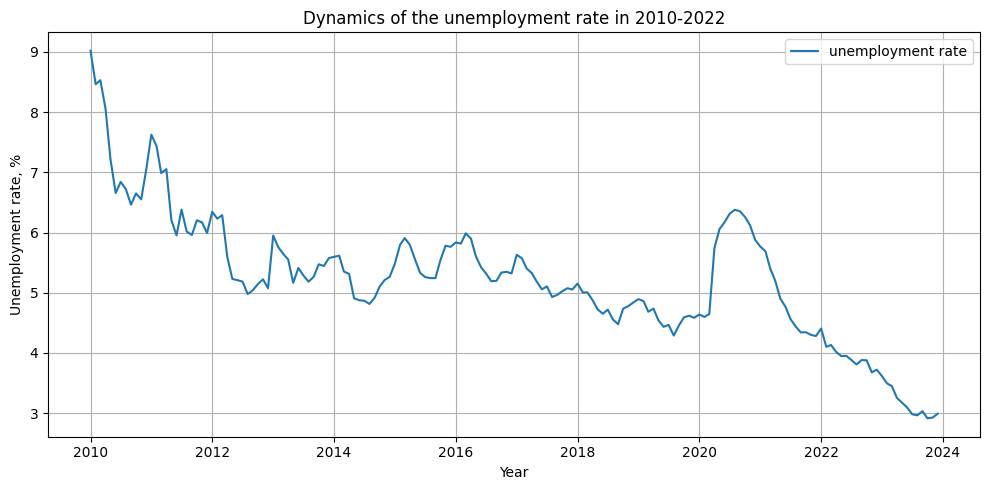

In [ ]:
plt.figure(figsize=(10, 5))
plt.title("Dynamics of the unemployment rate in 2010-2022")
plt.plot(unemp_df["date"], unemp_df[0], label="unemployment rate")
plt.grid()
plt.xlabel("Year")
plt.ylabel("Unemployment rate, %")
plt.legend()
plt.tight_layout()
plt.show()

Источник данных: Росстат

**Формулировка и проверка гипотез**

1. Сформулируйте 3 гипотезы о взаимосвязи между характеристиками (пол, возраст, регион, сфера деятельности и т.д.) и статусом участия в рабочей силе (занятые или безработные) или сектором занятости (формальный/неформальный). При формулировке гипотез обязательно приведите ссылки на релевантные, актуальные и авторитетные источники (научные исследования по схожей проблематике на зарубежном статистическом материале).

2. Проверьте ваши гипотезы на данных. Для этого сформулируйте необходимые разрезы данных, рассчитайте статистики, визуализируйте (в виде графиков или таблиц) ваши расчёты. Сделайте вывод о том, как результаты соотносятся со сформулированными гипотезами.

3. Кратко охарактеризуйте результаты вашего исследования в рамках одного абзаца текста.

## Гипотеза 1

Различия в уровне безработицы между мужчинами и женщинами зависят от возрастной группы: молодые женщины чаще сталкиваются с более высоким уровнем безработицы по сравнению с мужчинами того же возраста, в то время как в более старших возрастных группах уровень безработицы среди женщин ниже.

Данная гипотеза подтверждается зарубежными исследованиями:

Исследование 1: Согласно данным Международной организации труда, в 2021 году уровень безработицы среди женщин в возрасте 15 лет и старше составила 8,7%, среди мужчин — 6,7%, что указывает на значительный гендерный разрыв в безработице.
*(Wikipedia contributors. Women in the workforce// Wikipedia. // 2025. – Режим доступа: https://en.wikipedia.org/wiki/Women_in_the_workforce (дата обращения: 05.05.2025))*

Исследование 2:
Исследование выявило, что в некоторых странах ОЭСР, особенно в средиземноморском регионе, уровень безработицы среди женщин значительно выше, чем среди мужчин. . Например, в Испании уровень безработицы среди женщин в возрасте 25–54 лет составляет 21%, тогда как среди мужчин той же возрастной группы — 9,2%.Также авторы отмечают, что в странах с более выраженными гендерными различиями в уровне безработицы существует корреляция между этими различиями и социальными установками, предполагающими, что мужчины более достойны работы, чем женщины.
*(International Labour Organization. World Employment and Social Outlook: Trends 2021 // Geneva: ILO, 2021. – Режим доступа: https://www.ilo.org/wcmsp5/groups/public/---dgreports/---dcomm/documents/publication/wcms_794452.pdf (дата обращения: 05.05.2025))*

Из первых двух исследованй становится ясно, что безработица зависит от гендерного признака. Однако возможно зависимость не такая простая. Чтобы разобраться в этом вопросе подробнее, обратимся к исследованию 3:

Исследование 3:
В данном исследовании израильских женщин разделили на 4 возрастных категории: до 21 года, 22-35 лет, 36-49, 50-62. Исследование показало, что женщины из наиболее молодой возрастной группы стабильно тратили в неделю больше времени на поиски работы, чем женщины из оставшихся групп. В то же время в ходе исследования выяснилось, что женщины из наиболее возрастной категории реже всего отклоняли предложения о работе, в то время как молодые женщины часто отказывались от места в угоду семейной жизни.

(Kulik L. Women face unemployment: A comparative analysis of age groups //Journal of Career development. – 2000. – Т. 27. – С. 15-33.)

Выделим несколько возрастных групп:
- до 25 = 1
- 25 - 30 = 2
- 30 - 40 = 3
- 40 - 50 = 4
- 50 - 60 = 5
- от 60 = 6

Исследуем показатели для этих возрастных групп за 2023 год.

In [ ]:
data_2023 = ors_df[ors_df['year'] == 2023]  #отбираем данные за 2023 год
data_2023 = ors_df[["gender", "age", "labour_force_status", "vesa_ob"]]   #оставляем только нужные колонки
data_2023.head()

,gender,age,labour_force_status,vesa_ob
0,1,42,1,208.256944
1,2,39,1,193.479167
6,1,49,1,156.500000
9,2,54,1,126.212366
10,2,25,1,174.968254


In [ ]:
def get_age_groups(x):     #функция для деления на группы по возрасту
    if x["age"] <= 25:
        return 1
    elif 25 < x["age"] <= 30:
        return 2
    elif 30 < x["age"] <= 40:
        return 3
    elif 40 < x["age"] <= 50:
        return 4
    elif 50 < x["age"] <= 60:
        return 5
    elif x["age"] > 60:
        return 6
    else :
        return None

data_2023["age_groups"] = data_2023.apply(get_age_groups, axis=1)   #создаём столбец с делением на группы по возрасту
data_2023.head()

<ipython-input-19-4efc4eedfbf2>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2023["age_groups"] = data_2023.apply(get_age_groups, axis=1)   #создаём столбец с деление на группы по возрасту


,gender,age,labour_force_status,vesa_ob,age_groups
0,1,42,1,208.256944,4
1,2,39,1,193.479167,3
6,1,49,1,156.500000,4
9,2,54,1,126.212366,5
10,2,25,1,174.968254,1


In [ ]:
def get_unemployed_weight_ob(x):     #функция, оставляющая годовые веса безработных
    if x["labour_force_status"] == 2:
        return x["vesa_ob"]
    else:
        return 0

data_2023["unemployed_weight_ob"] = data_2023.apply(get_unemployed_weight_ob, axis=1)     #создаём столбец с обнулёнными годовыми весами занятых
data_2023.head()

<ipython-input-20-a04e666a824e>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2023["unemployed_weight_ob"] = data_2023.apply(get_unemployed_weight_ob, axis=1)     #создаём столбец с обнулёнными годовыми весами занятых


,gender,age,labour_force_status,vesa_ob,age_groups,unemployed_weight_ob
0,1,42,1,208.256944,4,0.0
1,2,39,1,193.479167,3,0.0
6,1,49,1,156.500000,4,0.0
9,2,54,1,126.212366,5,0.0
10,2,25,1,174.968254,1,0.0


In [ ]:
data_2023_for_edge_groups = data_2023.groupby(["gender", "age_groups"]).sum()["unemployed_weight_ob"] * 100 / data_2023.groupby(["gender", "age_groups"]).sum()["vesa_ob"]    #добавляем колонку с годовой безработицей по полу и возрастной группе

In [ ]:
data_2023_for_edge_groups = data_2023_for_edge_groups.reset_index()
data_2023_for_edge_groups.head()

,gender,age_groups,unemployment_rate_ob
0,1,1,13.070160
1,1,2,5.331373
2,1,3,4.425346
3,1,4,4.156280
4,1,5,4.439516


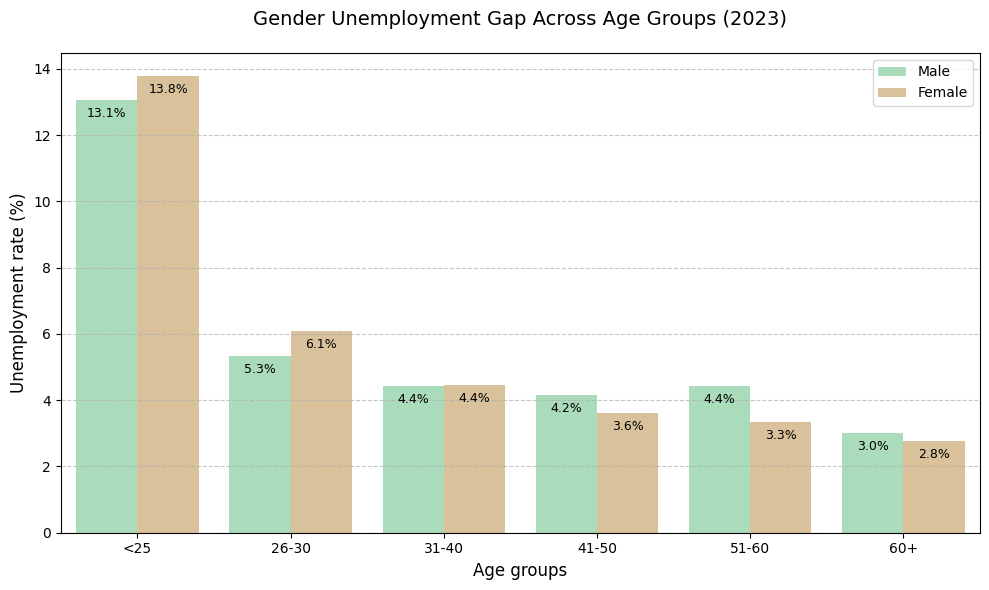

In [ ]:
import seaborn as sns

age_group_labels = {  #словарь для создания подписей в текстовом виде
    1: "<25",
    2: "26-30",
    3: "31-40",
    4: "41-50",
    5: "51-60",
    6: "60+"
}

gender_labels = {   #словарь для создания подписей в текстовом виде
    1: "Male",
    2: "Female"
}

data_2023_for_edge_groups["age_groups_text"] = data_2023_for_edge_groups["age_groups"].map(age_group_labels)
data_2023_for_edge_groups["gender_text"] = data_2023_for_edge_groups["gender"].map(gender_labels)

plt.figure(figsize=(10, 6))
sns.barplot(data=data_2023_for_edge_groups,  #создаём спаренные столбцы
            x="age_groups_text",
            y="unemployment_rate_ob",
            hue="gender_text",
            palette=["#A2E4B8", "#E2C391"])

plt.title("Gender Unemployment Gap Across Age Groups (2023)", fontsize=14, pad=20)
plt.xlabel("Age groups", fontsize=12)
plt.ylabel("Unemployment rate (%)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

for p in plt.gca().patches:     #создаём подписи над столбцами с их значениями
    if p.get_height() > 0:
        plt.gca().annotate(
            f"{p.get_height():.1f}%",
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha="center", va="top",
            xytext=(0, -5), textcoords="offset points", fontsize=9)

plt.legend()
plt.tight_layout()
plt.show()

Источник данных: Росстат

**Вывод:**

Данные за 2023 год показывают, что для молодого слоя населения уровень безработицы среди женщин выше, чем среди мужчин, однако среди людей среднего возраста уровни безработицы становятся одинаковыми, а с увеличением возрастной категория безработица среди мужчин начинает превалировать.
Диаграмма подтверждает нашу гипотезу. Скорее всего наблюдаемая зависимость обусловлена тем, что принимая на работу женщин молодого возраста, работодатели берут на себя дополнительные риски, а именно возможные декретные выплаты. При этом чем старше возрастная группа, в которой находится женщина, тем эти риски ниже.
Ещё одним важным фактором, влияющим на безработицу среди женщин и показывающим ее связь с возрастной группой, является тот факт, что сотрудники из молодых возрастных категорий чаще предъявляют определенные требования к условиям работы, позволяющие им совмещать ее с семейной жизнью (part-time job и другое). Таким образом их выбор ограничен, что также усиливает безработицу. В более возрастных категориях женщины, как правило, уделяют меньше времени семье, в результате чего их требования к специальным условиям работы ослабевают, соответственно найти вакансию для них становится проще, и безработица становится ниже.

# Гипотеза 2

Уровень безработицы снижается с ростом уровня образованности. Так, среди образованных слоев населения безработица ниже, чем среди низкообразованных людей и людей, не имеющих образования. То есть существует отрицательная зависимость между уровнем безработицы и уровнем образованности.

Данная гипотеза подтверждается зарубежными исследованиями.

Исследование 1:
Данные OECD показывают, что уровень занятости среди взрослых в возрасте 25–64 лет увеличивается с ростом уровня образования: 59% для лиц без полного среднего образования, 77% - имеющих среднее образование, и 86% - имеющих высшее образование.

*(OECD. Education at a Glance 2023: How does educational attainment affect participation in the labour market // OECD, 2023. – Режим доступа: https://www.oecd.org/en/publications/education-at-a-glance-2023_e13bef63-en/full-report/how-does-educational-attainment-affect-participation-in-the-labour-market_ebb370af.html (дата обращения: 05.05.2025))*

Исследование 2:
Исследование "Unemployment rates by education level" также показывает отрицательную зависимость между уровнем безработицы и уровнем образованности

*(OECD. Unemployment rates by education level // OECD Data. – 2023. – Режим доступа: https://www.oecd.org/en/data/indicators/unemployment-rates-by-education-level.html (дата обращения: 05.05.2025))*

Расчёты будут произведены на основе данных* 2023 года.

Обозначения: \\
- Среднее профессиональное образование по программе подготовки сп = 3
- Среднее профессиональное образование по программе подготовки кв = 4
- Среднее общее образование (ранее – среднее (полное) общее образов = 5
- Основное общее образование = 6
- Не имеете основного общего = 7
- Высшее образование  по программам подготовки научно-педагогичес = 8
- Высшее образование – бакалавриат = 9
- Высшее образование – специалитет (ранее – высшее профессиональн = 10
- Высшее образование – магистратура (ранее – высшее профессиональ = 11




Поделим людей на 3 группы по уровню образования: \\
- Низкий=1 (6-7)
- Средний=2 (3-5)
- Высокий=3 (8-11)

In [ ]:
df_2023 = ors_df[ors_df["year"] == 2023]  #отбираем данные за 2023 год
df_2023 = df_2023[["year", "month", "education", "labour_force_status", "vesa", "unemployed_weight"]]   #оставляем только нужные колонки
df_2023.head()

,year,month,education,labour_force_status,vesa,unemployed_weight
11338385,2023,1,3,1,2630.303797,0.0
11338386,2023,1,3,1,600.363636,0.0
11338388,2023,1,3,1,1057.702703,0.0
11338389,2023,1,5,1,830.666667,0.0
11338390,2023,1,6,1,702.366667,0.0


In [ ]:
def get_education_groups(x):     #функция для деления на группы по уровню образования
    if x["education"] in [6, 7]:
        return 1
    elif x["education"] in [3, 4, 5]:
        return 2
    elif x["education"] in [8, 9, 10, 11]:
        return 3
    else :
        return None

df_2023["education_groups"] = df_2023.apply(get_education_groups, axis=1)     #создаём столбец с деление на группы по уровню образования

In [ ]:
df_2023_unem_rate = df_2023.groupby(["year", "month", "education_groups"]).sum()["unemployed_weight"] * 100 / df_2023.groupby(["year", "month", "education_groups"]).sum()["vesa"] #рассчитываем для каждой группы безработицу
df_2023_unem_rate = df_2023_unem_rate.reset_index(name="unemployment_rate")
df_2023_unem_rate["date"] = pd.to_datetime(df_2023_unem_rate[["year", "month"]].assign(day=1))      #формируем полную дату

In [ ]:
df_2023_unem_rate.head()

,year,month,education_groups,unemployment_rate,date
0,2023,1,1,9.332429,2023-01-01
1,2023,1,2,4.119467,2023-01-01
2,2023,1,3,2.090052,2023-01-01
3,2023,2,1,9.682981,2023-02-01
4,2023,2,2,3.850056,2023-02-01


In [ ]:
gr1 = df_2023_unem_rate[df_2023_unem_rate["education_groups"] == 1]     #отделяем данные для каждой группы
gr2 = df_2023_unem_rate[df_2023_unem_rate["education_groups"] == 2]
gr3 = df_2023_unem_rate[df_2023_unem_rate["education_groups"] == 3]

In [ ]:
average_gr1 = gr1["unemployment_rate"].mean()
print(f"Средний уровень безработицы среди людей с низшим уровнем образования: {average_gr1}")

average_gr2 = gr2["unemployment_rate"].mean()
print(f"Средний уровень безработицы среди людей со средним уровнем образования: {average_gr2}")

average_gr3 = gr3["unemployment_rate"].mean()
print(f"Средний уровень безработицы среди людей с высшим уровнем образования: {average_gr3}")

Средний уровень безработицы среди людей с низшим уровнем образования: 8.49399643071525
Средний уровень безработицы среди людей со средним уровнем образования: 3.497903002809343
Средний уровень безработицы среди людей с высшим уровнем образования: 1.9182785214059141


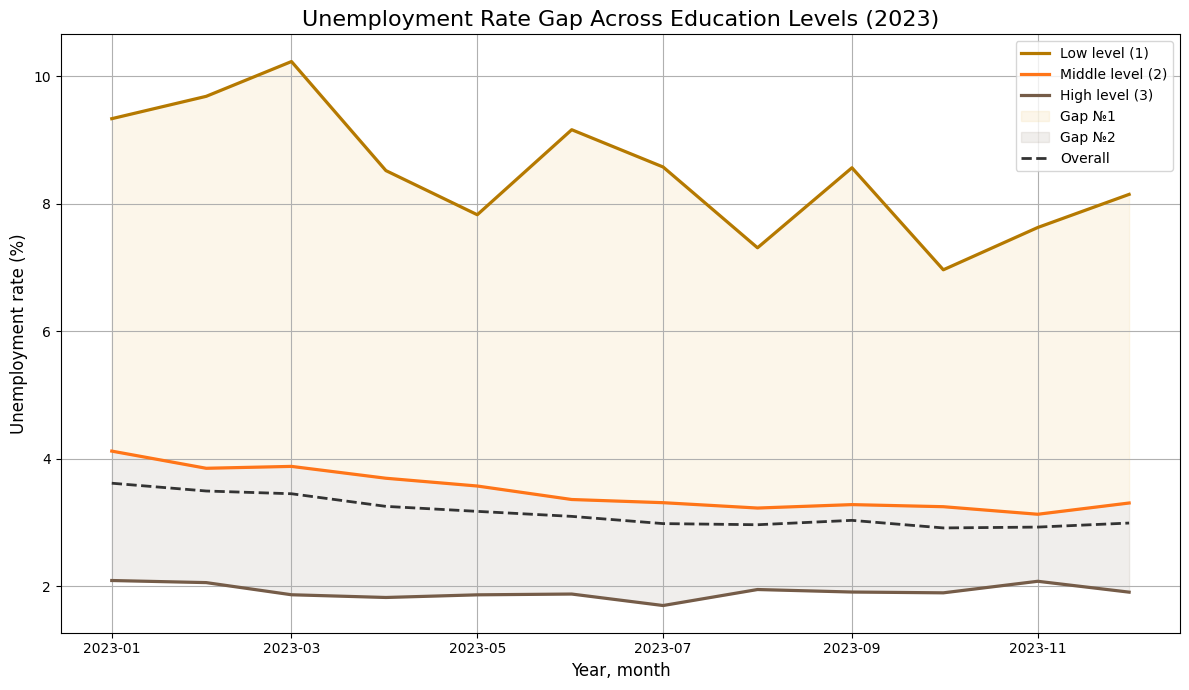

In [ ]:
plt.figure(figsize=(12, 7))

plt.title("Unemployment Rate Gap Across Education Levels (2023)", fontsize=16)

plt.plot(gr1["date"], gr1["unemployment_rate"], label="Low level (1)", color="#B57900", linewidth=2.3)      #строим график по среднемесячному уровню безработицы для каждой группы
plt.plot(gr2["date"], gr2["unemployment_rate"], label="Middle level (2)", color="#FF7518", linewidth=2.3)
plt.plot(gr3["date"], gr3["unemployment_rate"], label="High level (3)", color="#755C48", linewidth=2.3)

plt.fill_between(gr1["date"], gr1["unemployment_rate"], gr2["unemployment_rate"], color="#F0D698", alpha=0.2, label="Gap №1")   #раскрашиваем гэп между группами
plt.fill_between(gr2["date"], gr2["unemployment_rate"], gr3["unemployment_rate"], color="#755C48", alpha=0.1, label="Gap №2")

plt.plot(unemp_df[unemp_df["year"] == 2023]["date"], unemp_df[unemp_df["year"] == 2023][0], linewidth=2, linestyle="--", color="#333333", label="Overall")
plt.grid()
plt.xlabel("Year, month", fontsize=12)
plt.ylabel("Unemployment rate (%)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

*Источник данных: Росстат

**Вывод:**

Предоставленные данные за 2023 год подтвердили нашу гипотезу, что означает, что чем выше уровень образования у категории людей, тем меньше среди них безработица. То есть при поиске сотрудников работодатели отдают предпочтения квалифицированным кадрам.
Желание работодателей принимать на работу более квалифицированных сотрудников вероятно обусловлено тем, что это снижает затраты компании на обучение работников. Помимо этого, считается, что более квалифицированные сотрудники справляются с рабочими задачами качественнее и быстрее.
Также график показывает, что среди людей с низким уровнем образованности наблюдаются значительные колебания уровня безработицы во времени, в то время как положение более образованных слоев относительно стабильно. Возможно, это связано с тем, что необразованных и низкообразованных сотрудников берут на работу менее надёжные компании, в результате чего им приходится чаще менять место работы. Также возможно, если исходить из идеи о том, что более квалифицированные сотрудники работают лучше, можно предложить, что необразованных и низкообразованных работников чаще увольняют в виду их некачественной работы, что также приводит к значительным колебаниям безработицы во времени, которые мы наблюдаем на графике.

# Гипотеза 3

Уровень неформально занятых отрицательно зависит от численности населения в регионе и его развитости. То есть чем менее крупный и экономически развитый регион, тем большую часть рынка труда на себя забирает теневой сектор.

Данная гипотеза подтверждается зарубежными исследованиями:

Исследование1:
Исследование "How informal economies are shaped by global capital" анализирует, почему неформальная занятость преобладает в менее развитых регионах.

*(McDermott, J. L. Mexico City, Freetown and the Global Division of Urban Informal Labour // Urban Studies. – 2025. – Vol. 62 – Режим доступа: https://journals.sagepub.com/doi/10.1177/00420980241269659 (дата обращения: 05.05.2025))*

Исследование 2: Доклад "Breaking the Vicious Circles of Informal Employment and Low-Paying Work" указывает на то, что неформальная занятость часто является следствием ограниченности доступа к качественному образованию и социальным услугам, что характерно для периферийных регионов.

*(OECD. Breaking the Vicious Circles of Informal Employment and Low-Paying Work // Paris: OECD Publishing, 2024. - 120 p. – Ружим доступа: https://www.oecd.org/en/publications/breaking-the-vicious-circles-of-informal-employment-and-low-paying-work_f95c5a74-en.html (дата обращения: 05.05.2025))*

Обозначения:
- Город=1
- Село=2

In [ ]:
data_set_type = ors_df[["year", "quarter", "vesa_kvart", "settlement_type", "labour_force_status", "informal_employment"]]  #оставляем только нужные столбцы

In [ ]:
data_set_type.head()

,year,quarter,vesa_kvart,settlement_type,labour_force_status,informal_employment
0,2010,1,833.027778,1,1,1
1,2010,1,773.916667,1,1,0
6,2010,1,626.000000,1,1,1
9,2010,1,504.849462,1,1,0
10,2010,1,699.873016,1,1,0


In [ ]:
data_set_type = data_set_type[data_set_type["labour_force_status"] == 1]    #оставляем только занятых

In [ ]:
data_set_type["formal_employment_weight"] = data_set_type["vesa_kvart"] * (1 - data_set_type["informal_employment"])   #создаём колонку весов формально занятых
data_set_type["informal_employment_weight"] = data_set_type["vesa_kvart"] * data_set_type["informal_employment"]   #создаём колонку весов формально неформально занятых


In [ ]:
data_set_type.head()

,year,quarter,vesa_kvart,settlement_type,labour_force_status,informal_employment,formal_employment_weight,informal_employment_weight
0,2010,1,833.027778,1,1,1,0.0,833.027778
1,2010,1,773.916667,1,1,0,773.916667,0.0
6,2010,1,626.000000,1,1,1,0.0,626.0
9,2010,1,504.849462,1,1,0,504.849462,0.0
10,2010,1,699.873016,1,1,0,699.873016,0.0


In [ ]:
data_set_type_sum = (data_set_type.groupby(["year", "quarter", "settlement_type"])   #суммируем кол-во формально и неформально занятых
                    .agg(informal_sum=("informal_employment_weight", "sum"),
                        formal_sum=("formal_employment_weight", "sum")).reset_index())

In [ ]:
data_set_type_sum.head()

,year,quarter,settlement_type,informal_sum,formal_sum
0,2010,1,1,6403530.501578,46063175.844425
1,2010,1,2,4070986.207292,11623333.517121
2,2010,2,1,6830739.637,46765101.889701
3,2010,2,2,4873600.189271,11671076.602533
4,2010,3,1,7607013.147134,46765623.105135


In [ ]:
data_set_type_sum["informal_share"] = (data_set_type_sum["informal_sum"] * 100 /   #рассчитываем процент неформально занятых
                                      (data_set_type_sum["informal_sum"] +
                                       data_set_type_sum["formal_sum"])).round(2)    #точность до 2 знаков

In [ ]:
data_set_type_sum.head()

,year,quarter,settlement_type,informal_sum,formal_sum,informal_share
0,2010,1,1,6403530.501578,46063175.844425,12.2
1,2010,1,2,4070986.207292,11623333.517121,25.94
2,2010,2,1,6830739.637,46765101.889701,12.74
3,2010,2,2,4873600.189271,11671076.602533,29.46
4,2010,3,1,7607013.147134,46765623.105135,13.99


In [ ]:
data_set_type_sum["date"] = pd.to_datetime(data_set_type_sum["year"].astype(str) + "-" +
 (data_set_type_sum["quarter"]*3-2).astype(str) + "-01")    #формируем полную дату

In [ ]:
data_set_type_sum.head()

,year,quarter,settlement_type,informal_sum,formal_sum,informal_share,date
0,2010,1,1,6403530.501578,46063175.844425,12.2,2010-01-01
1,2010,1,2,4070986.207292,11623333.517121,25.94,2010-01-01
2,2010,2,1,6830739.637,46765101.889701,12.74,2010-04-01
3,2010,2,2,4873600.189271,11671076.602533,29.46,2010-04-01
4,2010,3,1,7607013.147134,46765623.105135,13.99,2010-07-01


In [ ]:
data_city = data_set_type_sum[data_set_type_sum["settlement_type"] == 1]    #отделяем города
data_town = data_set_type_sum[data_set_type_sum["settlement_type"] == 2]    #отделяем сёла

Посчитаем общую долю неформально занятых.

In [ ]:
data_overall = (data_set_type_sum.groupby(["year", "quarter"])
                    .agg(informal_sum=("informal_sum", "sum"),
                        formal_sum=("formal_sum", "sum"))).reset_index()

data_overall["informal_share"] = (data_overall["informal_sum"] * 100 /   #рассчитываем процент неформально занятых
                                      (data_overall["informal_sum"] + data_overall["formal_sum"])).round(2)

data_overall["date"] = pd.to_datetime(data_overall["year"].astype(str) + "-" +
 (data_overall["quarter"]*3-2).astype(str) + "-01")    #формируем полную дату

In [ ]:
data_overall.head()

,year,quarter,informal_sum,formal_sum,informal_share,date
0,2010,1,10474516.708871,57686509.361546,15.37,2010-01-01
1,2010,2,11704339.826271,58436178.492233,16.69,2010-04-01
2,2010,3,12921144.538205,58250988.683021,18.15,2010-07-01
3,2010,4,10829715.419465,59431440.816236,15.41,2010-10-01
4,2011,1,11999769.178073,57505140.01459,17.26,2011-01-01


Посчитаем годовые значения.

In [ ]:
data_set_type_year = ors_df[["year", "vesa_ob", "settlement_type", "labour_force_status", "informal_employment"]]  #оставляем только нужные столбцы

data_set_type_year = data_set_type_year[data_set_type_year["labour_force_status"] == 1]    #оставляем только занятых

data_set_type_year["formal_employment_weight"] = data_set_type_year["vesa_ob"] * (1 - data_set_type_year["informal_employment"])   #создаём колонку весов формально занятых
data_set_type_year["informal_employment_weight"] = data_set_type_year["vesa_ob"] * data_set_type_year["informal_employment"]   #создаём колонку весов формально неформально занятых

data_set_type_year_sum = (data_set_type_year.groupby(["year", "settlement_type"])   #суммируем кол-во формально и неформально занятых
                    .agg(informal_sum=("informal_employment_weight", "sum"),
                        formal_sum=("formal_employment_weight", "sum")).reset_index())

data_set_type_year_sum["informal_share"] = (data_set_type_year_sum["informal_sum"] * 100 /   #рассчитываем процент неформально занятых
                                      (data_set_type_year_sum["informal_sum"] +
                                       data_set_type_year_sum["formal_sum"])).round(2)    #точность до 2 знаков

data_set_type_year_sum["date"] = pd.to_datetime(data_set_type_year_sum["year"].astype(str) + "-01-01")  #формируем полную дату

data_city_year = data_set_type_year_sum[data_set_type_year_sum["settlement_type"] == 1]    #отделяем города
data_town_year = data_set_type_year_sum[data_set_type_year_sum["settlement_type"] == 2]    #отделяем сёла

Посчитаем общую годовую долю неформально занятых.

In [ ]:
data_overall_year = (data_set_type_year_sum.groupby(["year"])
                    .agg(informal_sum=("informal_sum", "sum"),
                        formal_sum=("formal_sum", "sum"))).reset_index()

data_overall_year["informal_share"] = (data_overall_year["informal_sum"] * 100 /   #рассчитываем процент неформально занятых
                                      (data_overall_year["informal_sum"] + data_overall_year["formal_sum"])).round(2)

data_overall_year["date"] = pd.to_datetime(data_overall_year["year"].astype(str) + "-01-01")  #формируем полную дату

In [ ]:
data_overall_year.head()

,year,informal_sum,formal_sum,informal_share,date
0,2010,11482429.123203,58451279.338259,16.42,2010-01-01
1,2011,12921935.627978,57934677.485374,18.24,2011-01-01
2,2012,13599801.76266,57945614.100923,19.01,2012-01-01
3,2013,14114432.999924,57360487.018993,19.75,2013-01-01
4,2014,14419632.333608,57268181.587595,20.11,2014-01-01


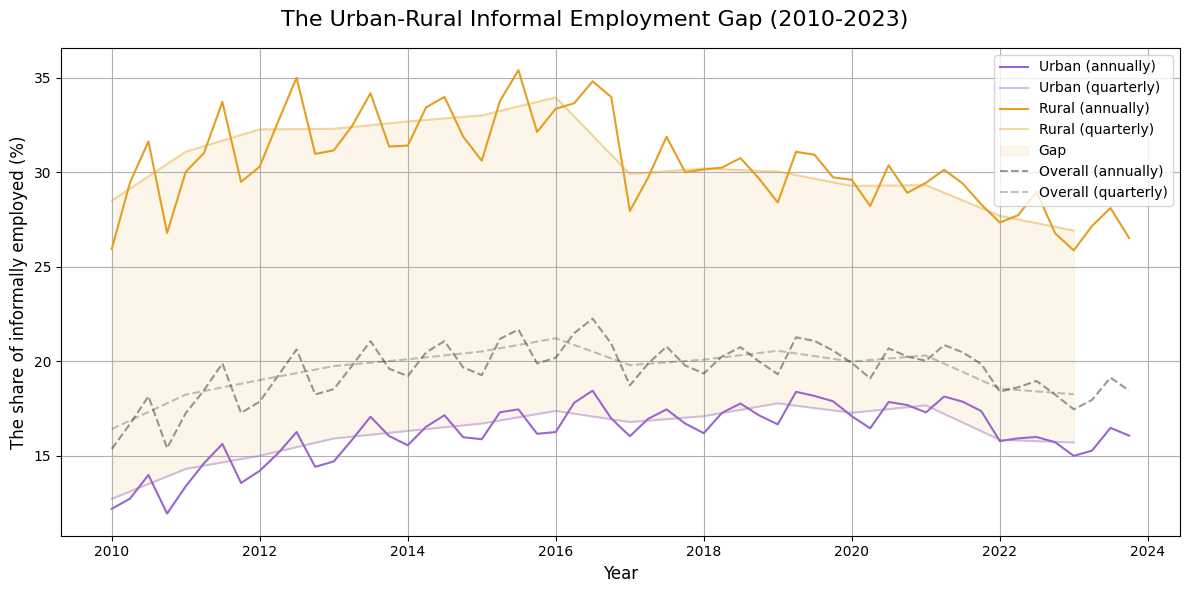

In [ ]:
plt.figure(figsize=(12, 6))
plt.suptitle("The Urban-Rural Informal Employment Gap (2010-2023)", fontsize=16)

plt.plot(data_city["date"], data_city["informal_share"], label="Urban (annually)", color="#9966CC")      #поквартальная доля в городе
plt.plot(data_city_year["date"], data_city_year["informal_share"], label="Urban (quarterly)", color="#9966CC", alpha=0.4)  #годовая доля в городе

plt.plot(data_town["date"], data_town["informal_share"], label="Rural (annually)", color="#E59E1F")   #поквартальная доля в селе
plt.plot(data_town_year["date"], data_town_year["informal_share"], label="Rural (quarterly)", color="#E59E1F", alpha=0.4)   #годовая доля в селе

plt.fill_between(data_city_year["date"], data_city_year["informal_share"], data_town_year["informal_share"], color="#F0D698", alpha=0.2, label="Gap")

plt.plot(data_overall["date"], data_overall["informal_share"], label="Overall (annually)", linestyle="--", color="#333333", alpha=0.5)    #поквартальная общаяя доля
plt.plot(data_overall_year["date"], data_overall_year["informal_share"], label="Overall (quarterly)", linestyle="--", color="#333333", alpha=0.3)   #годовая общая доля

plt.grid()
plt.xlabel("Year", fontsize=12)
plt.ylabel("The share of informally employed (%)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

**Вывод:** Исходя из полученного графика, можно сделать вывод о том, что люди в сельской местности заняты в неформальном секторе почти в два раза чаще, чем в городе. Однако примерно в 2017 году процент работающих неформально заметно сократился: занятых в неформальном секторе в селе стало стабильно больше почти в 1,5 раза, чем занятых в неформальном секторе в городе.
Данные показывают, что гипотеза верна. Наблюдаемая зависимость может быть обусловлена тем, что в селах контроль над неформальным сектором значительно ниже. Таким образом, соотношение рабочих мест в формальном и теневом секторе сильно отличается от того, что мы наблюдаем в городах: в селах преобладают неформальные рабочие места, в то время как в городах - наоборот.

# Итоги

В ходе исследования наши гипотезы были подтверждены: различие в уровне безработицы зависит от пола, возраста, уровня образования и места проживания человека. Актуальность исследования обусловлена необходимостью осознавать, какие факторы влияют на безработицу. Эта информация важна для обеспечения эффективного государственного регулирования в данной сфере. Исходя из исследований, приведенных в работе (OECD, ILO и другие), можно сделать вывод, что гендерные различия, уровень образования и неформальная занятость продолжают оказывать заметное влияние на рынок труда. Анализ данных показал, что молодые женщины чаще сталкиваются с безработицей, чем молодые мужчины (разница составляет примерно 0,7 п. п.), однако с возрастом ситуация становится обратной (разница становится нулевая, а потом составляет 0,2–0,9  п. п.). Также выяснилось, что люди с высшим или средним образованием реже остаются без работы (уровень безработицы ниже в 3–5 раз), по сравнению с теми, у кого уровень образования ниже, и колебания показателя безработицы у последних выше. Данные по последней гипотезе иллюстрируют, что в сельской местности доля неформально занятых в 1,5–2  раза выше, чем в городах.
Таким образом, в результате анализа, мы выяснили, что такие социально - демографические и экономические особенности, как возраст, пол, образование и место жительства оказывают значительное влияние на уровень безработицы. Соответственно, в процессе регулирования уровня безработицы необходимо внимательно учитывать эти показатели и зависимости, существующие между ними.